In [13]:
import numpy as np 
import pandas as pd
import seaborn as sns 
from sklearn.datasets import load_breast_cancer

In [14]:
data = load_breast_cancer()
x = pd.DataFrame(data.data , columns=data.feature_names)
y = pd.Series(data.target , name="Target")

In [15]:
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [16]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Target, dtype: int64

In [17]:
print(x.shape , y.value_counts() , sep="\n")

(569, 30)
Target
1    357
0    212
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=42 , stratify=y)

In [19]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [20]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
y_pred = model.predict(x_test_scaled)
y_prob = model.predict_proba(x_test_scaled)[:,1]

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score 
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9824561403508771
ROC AUC: 0.9953703703703703

Confusion Matrix:
 [[41  1]
 [ 1 71]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [23]:
coef_df = pd.DataFrame({
    "feature": x.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)
print(coef_df.head(10))

                 feature  coefficient
21         worst texture    -1.255088
10          radius error    -1.082965
27  worst concave points    -0.953686
23            worst area    -0.947756
20          worst radius    -0.947616
28        worst symmetry    -0.939181
13            area error    -0.929104
26       worst concavity    -0.823151
22       worst perimeter    -0.763220
24      worst smoothness    -0.746625


<Axes: >

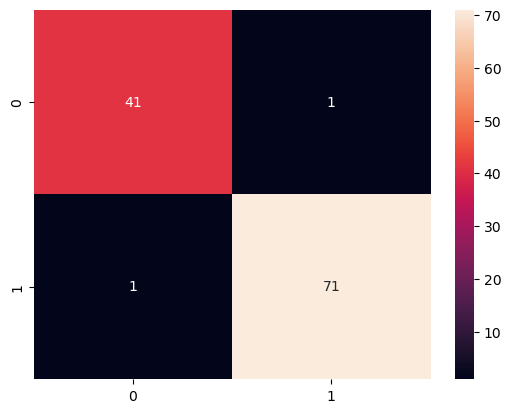

In [26]:
sns.heatmap(confusion_matrix(y_test, y_pred),annot=True)